# Configuração 2 — suavizar antes de mexer no contraste

**ruído → mediana 3×3 → gama γ = 1,5 → high-boost**

Diferença para a configuração 1: remove o ruído **primeiro** e troca a equalização pelo gama.

In [1]:
import sys
sys.path.insert(0, "../src")

from pdi import pipeline
from pdi.gustavo import io_utils
from pdi.gustavo import operacoes_pontuais as op
from pdi.heloisa import ruido, suavizacao
from pdi.joao import agucamento, metricas

IMAGENS = {
    "ISIC_0014049": "../data/originais/ISIC_0014049.jpg",  # baixo contraste
    "ISIC_7236365": "../data/originais/ISIC_7236365.jpg",  # pelos densos
    "ISIC_0021531": "../data/originais/ISIC_0021531.jpg",  # bordas difusas
}

CONFIG = [
    ("degradada", lambda im: ruido.ruido_gaussiano(im, sigma=15, semente=42)),
    ("suavizada", lambda im: suavizacao.filtro_mediana(im, tamanho=3)),
    ("gama",      lambda im: op.correcao_gama(im, 1.5)),
    ("agucada",   lambda im: agucamento.high_boost(im, tamanho=3, sigma=1.0, k=1.5)),
]

## Execução nas 3 imagens

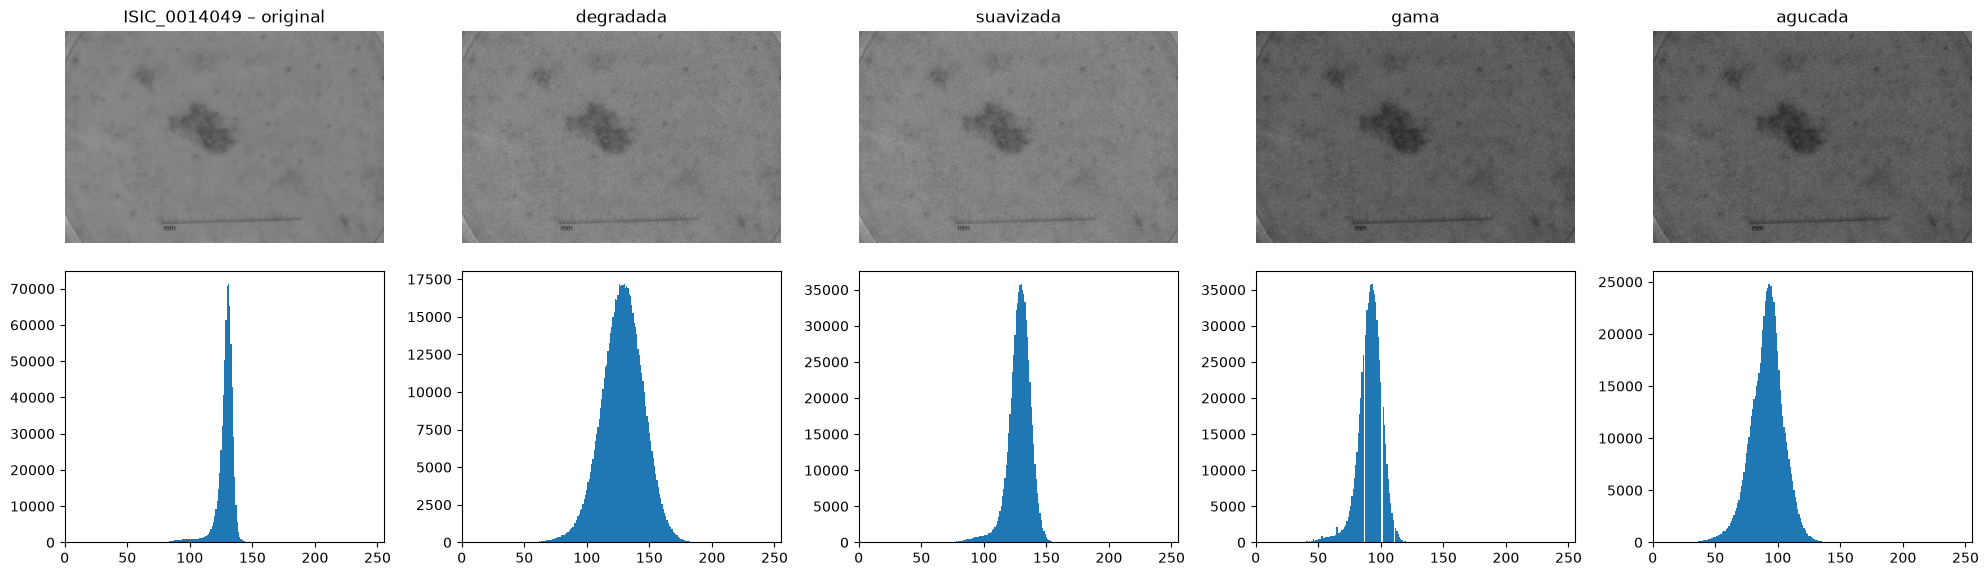

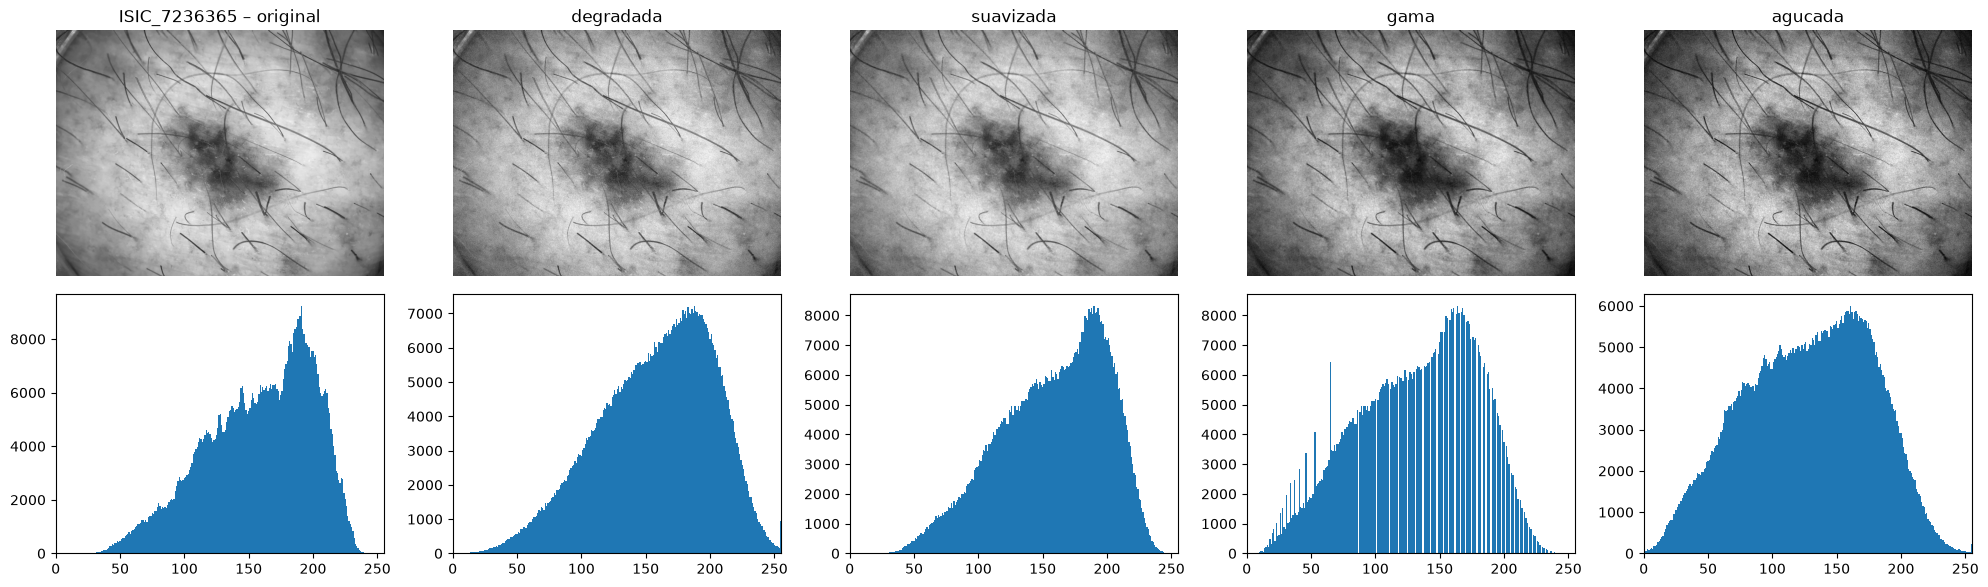

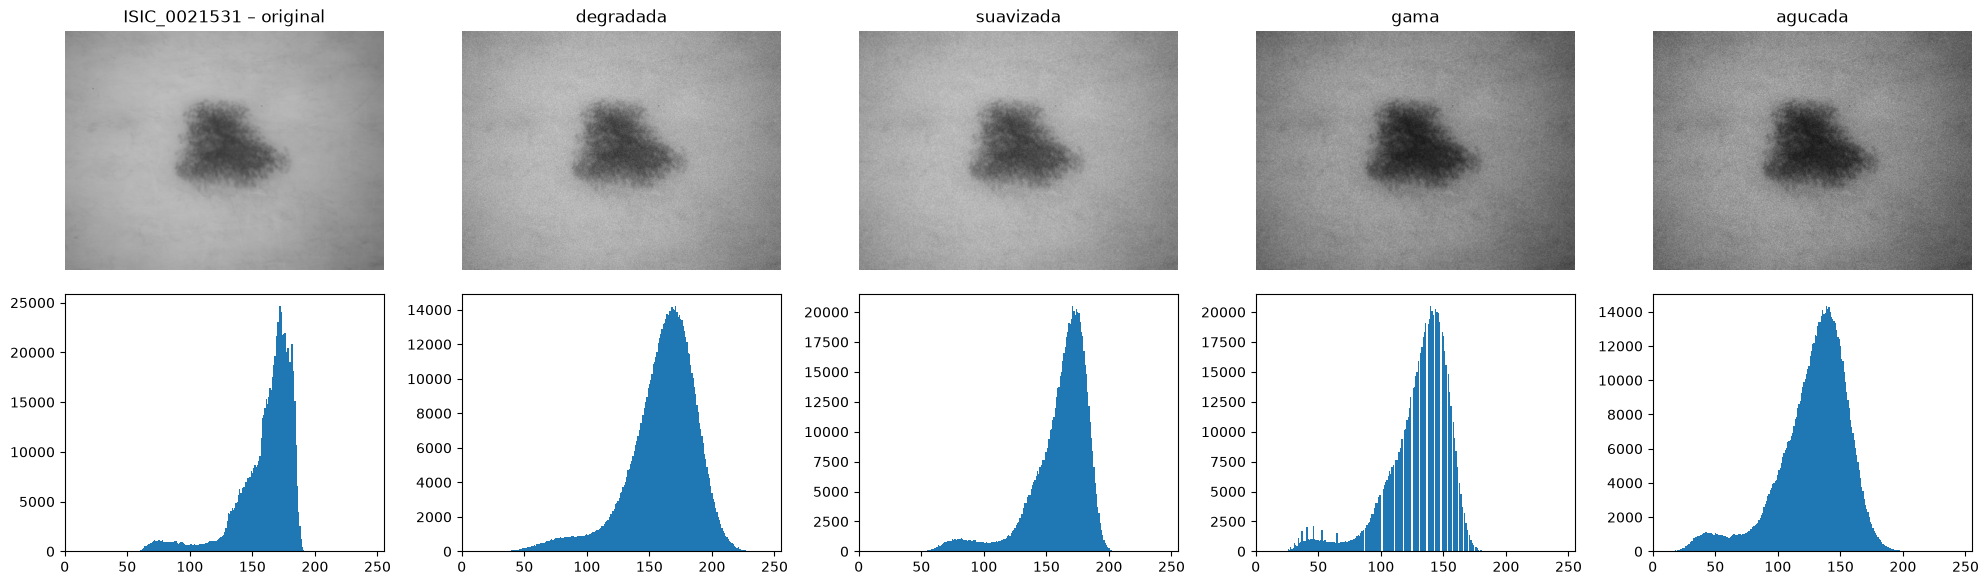

In [2]:
resultados = {}
for nome, caminho in IMAGENS.items():
    img = io_utils.carregar_cinza(caminho, largura_max=1024)
    resultados[nome] = pipeline.executar(img, CONFIG)
    io_utils.mostrar(pipeline.imagens(resultados[nome]), [f"{nome} – {e}" if e == "original" else e
                                                         for e in pipeline.nomes(resultados[nome])])

## Métricas (referência: original sem ruído)

In [3]:
print(f"{'Imagem':<14}{'Estágio':<12}{'PSNR (dB)':>10}{'SSIM':>8}")
for nome, res in resultados.items():
    original = res[0][1]
    for etapa, im in res[1:]:
        print(f"{nome:<14}{etapa:<12}{metricas.psnr(original, im):>10.2f}{metricas.ssim(original, im):>8.3f}")
    print()

Imagem        Estágio      PSNR (dB)    SSIM


ISIC_0014049  degradada        24.60   0.240


ISIC_0014049  suavizada        32.22   0.664


ISIC_0014049  gama             16.60   0.599


ISIC_0014049  agucada          16.37   0.357



...

ISIC_7236365  agucada          17.57   0.464



ISIC_0021531  degradada        24.60   0.232


ISIC_0021531  suavizada        32.31   0.662


ISIC_0021531  gama             17.75   0.569


ISIC_0021531  agucada          17.38   0.320



## Veredito

| | Config 1 | Config 2 |
|---|---|---|
| SSIM após a suavização | 0,21 / 0,62 / 0,28 | **0,66 / 0,74 / 0,66** |
| SSIM final | 0,12 / **0,51** / 0,17 | **0,36** / 0,46 / **0,32** |
| PSNR final (dB) | **17,5** / 15,5 / 14,1 | 16,4 / **17,6** / **17,4** |

*(ordem: ISIC_0014049 / ISIC_7236365 / ISIC_0021531)*

- ✅ **Suavizar primeiro funciona:** a mediana leva o PSNR de ~24,6 para ~31–32 dB antes de qualquer realce.
- ✅ **Imagem limpa e fiel:** melhor resultado em ISIC_7236365 e ISIC_0021531.
- ❌ **Gama quase não aumenta o contraste** da ISIC_0014049 (desvio 7,4 → 7,6).
- ❌ **γ fixo falha na imagem escura:** γ = 1,5 escurece ainda mais e a lesão some (teste abaixo).
- **Melhor compromisso geral**, mas o γ deveria ser escolhido por imagem.

## Teste com imagem nova
Na imagem escura, o γ = 1,5 escurece demais (compare com a configuração 1).

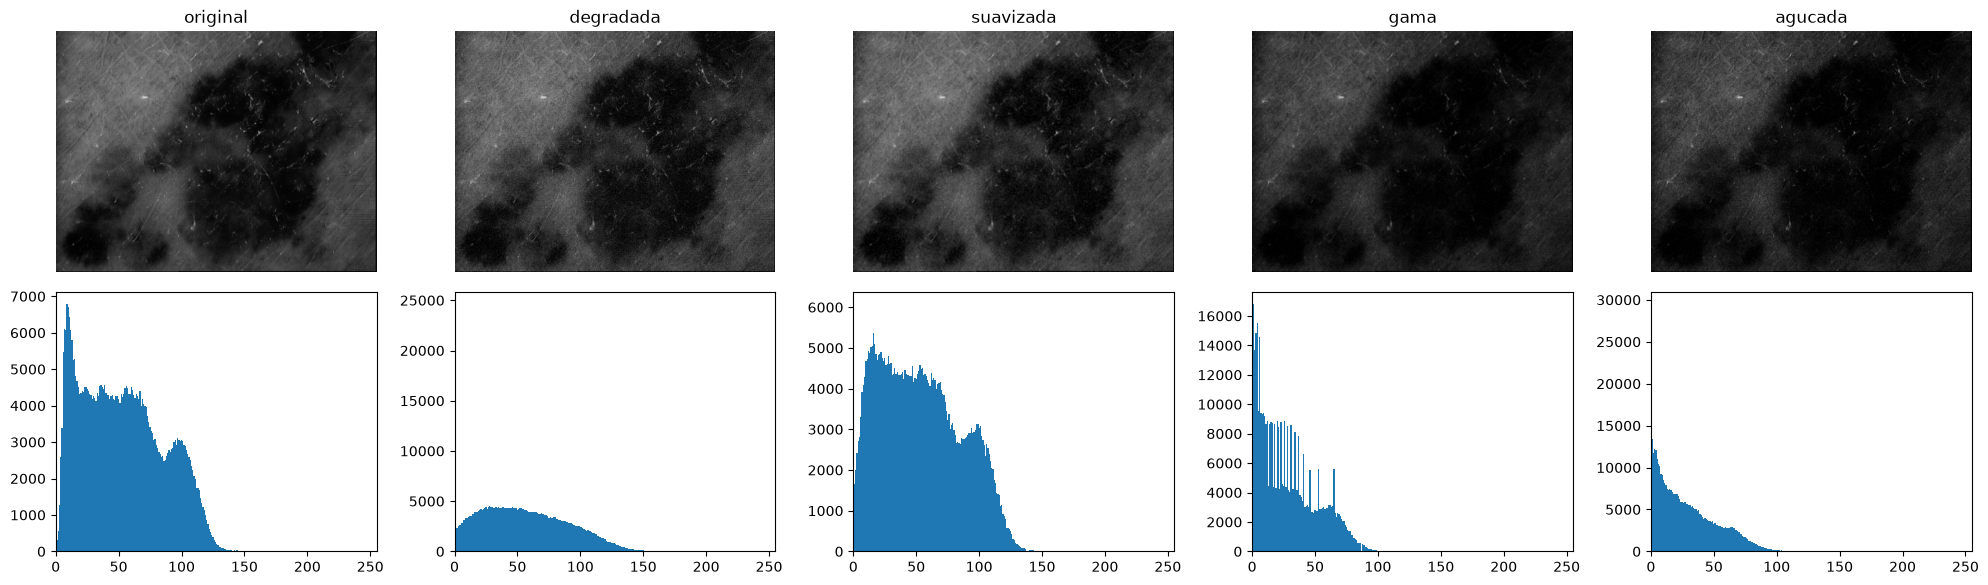

degradada    PSNR  24.94 dB   SSIM 0.397


suavizada    PSNR  31.05 dB   SSIM 0.699


gama         PSNR  19.16 dB   SSIM 0.539


agucada      PSNR  19.01 dB   SSIM 0.459


In [4]:
IMAGEM_TESTE = "../data/originais/ISIC_0112420.jpg"  # troque por qualquer imagem

img = io_utils.carregar_cinza(IMAGEM_TESTE, largura_max=1024)
res = pipeline.executar(img, CONFIG)
io_utils.mostrar(pipeline.imagens(res), pipeline.nomes(res))
for etapa, im in res[1:]:
    print(f"{etapa:<12} PSNR {metricas.psnr(img, im):6.2f} dB   SSIM {metricas.ssim(img, im):.3f}")